# Notebook 04 — Detection Gap Analysis

This notebook produces the project's primary deliverable: a three-panel map identifying where spotted lanternfly (*Lycorma delicatula*) is most likely to go undetected in Great Smoky Mountains National Park.

The logic combines two surfaces:
- **Habitat suitability** from notebook 03 — the Random Forest model's prediction of relative habitat quality for SLF across the park (values in [0, 0.458], where higher = more suitable)
- **Observer effort** — a proxy for where naturalists have been active, derived from all iNaturalist observations in the study extent

A **detection gap score** (`suitability × (1 − effort)`) is high where the model predicts suitable habitat *and* observers have been absent. These are the cells that, if SLF has arrived in the park, we'd be least likely to have already found it. The final figure overlays roads and trails on all three panels so the gap scores can be interpreted in terms of access.

In [1]:
import time
from pathlib import Path

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from matplotlib.ticker import FuncFormatter
from pyproj import Transformer
from pygbif import occurrences
from rasterio.transform import rowcol
from scipy.ndimage import gaussian_filter

## Load Suitability Raster

All output rasters in this notebook must share the same grid as `suitability.tif` — the same transform, CRS, shape, and nodata convention. Reading grid parameters once here and reusing them throughout avoids any possibility of off-by-one misalignment in the output stack.

The valid-pixel mask (`valid`) is `True` where the model produced a prediction. NaN pixels outside this mask are the cells outside the GSMNP study extent — they stay NaN in every output.

In [2]:
with rasterio.open('./data/suitability.tif') as src:
    suitability = src.read(1)          # (H, W) float32
    grid_meta   = src.meta.copy()
    grid_xf     = src.transform
    grid_bounds = src.bounds

H, W   = suitability.shape
valid  = ~np.isnan(suitability)

print(f"Grid: {H}×{W}, CRS: {grid_meta['crs']}")
print(f"Bounds (EPSG:5070): {grid_bounds}")
print(f"Valid pixels: {valid.sum():,}")
print(f"Suitability — min: {suitability[valid].min():.4f}  max: {suitability[valid].max():.4f}  "
      f"mean: {suitability[valid].mean():.4f}")

Grid: 286×437, CRS: EPSG:5070
Bounds (EPSG:5070): BoundingBox(left=1064000.0, bottom=1436750.0, right=1173250.0, top=1508250.0)
Valid pixels: 81,715
Suitability — min: 0.0000  max: 0.4580  mean: 0.0395


## Load NPS Shapefiles

The GSMNP boundary, roads, and trail network will be overlaid on all three map panels. The shapefiles are in their native CRS; we reproject to EPSG:5070 so they share the same coordinate system as the rasters and can be plotted directly onto the axes without any further transformation.

In [3]:
boundary = gpd.read_file('./data/nps/BOUNDARY_PY.shp').to_crs('EPSG:5070')
roads    = gpd.read_file('./data/nps/GRSM_ROADS.shp').to_crs('EPSG:5070')
trails   = gpd.read_file('./data/nps/GRSM_TRAILS.shp').to_crs('EPSG:5070')

print(f"Boundary: {len(boundary)} polygon(s)")
print(f"Roads:    {len(roads):,} segments")
print(f"Trails:   {len(trails):,} segments")

Boundary: 19 polygon(s)
Roads:    1,925 segments
Trails:   548 segments


## Load Land Cover

Band 6 of `env_predictors.tif` is the NLCD 2021 land cover classification. Three classes will be masked out of the gap score (and from suitability and effort for visual consistency): open water (11), barren land (31), and emergent herbaceous wetlands (95). These classes have no suitable SLF host plants and are generally inaccessible to foot observers, so a gap score there is meaningless.

Developed land (21–24) is retained — *Ailanthus altissima*, SLF's primary host, colonizes road cuts, parking areas, and developed edges throughout the Smokies, making developed cells the highest-priority early-detection sites.

In [7]:
with rasterio.open('./data/env_stack/env_predictors.tif') as src:
    lc_raw = src.read(6)   # float32, NaN outside study extent

# Fill NaN (out-of-extent pixels) with 0 before casting — 0 is not a valid NLCD class
landcover = np.where(np.isnan(lc_raw), 0, lc_raw).astype(np.int32)

lc_mask = np.isin(landcover, [11, 31, 95]) & valid

classes, counts = np.unique(landcover[valid], return_counts=True)
print("Land cover classes present in study area:")
for cls, cnt in zip(classes, counts):
    flag = " ← masked" if cls in [11, 31, 95] else ""
    print(f"  {int(cls):3d}: {cnt:6,} pixels{flag}")

Land cover classes present in study area:
   11:    979 pixels ← masked
   21:  4,375 pixels
   22:  1,054 pixels
   23:    534 pixels
   24:    127 pixels
   31:     67 pixels ← masked
   41: 36,348 pixels
   42:  6,479 pixels
   43: 26,425 pixels
   52:    371 pixels
   71:    288 pixels
   81:  4,408 pixels
   82:    194 pixels
   90:     53 pixels
   95:     13 pixels ← masked


## Derive Bounding Box for GBIF Query

The iNaturalist fetch uses a WKT POLYGON geometry in EPSG:4326. The raster extent is in EPSG:5070 (meters), so we transform the four corners to geographic coordinates using `pyproj.Transformer`. A 0.01° buffer is added to ensure that observations on the edge of the study extent aren't dropped by floating-point rounding in the API's spatial filter.

In [8]:
t_4326 = Transformer.from_crs('EPSG:5070', 'EPSG:4326', always_xy=True)

lon_min, lat_min = t_4326.transform(grid_bounds.left,  grid_bounds.bottom)
lon_max, lat_max = t_4326.transform(grid_bounds.right, grid_bounds.top)

buf = 0.01
lon_min -= buf;  lat_min -= buf
lon_max += buf;  lat_max += buf

bbox_wkt = (
    f"POLYGON(({lon_min:.5f} {lat_min:.5f}, "
    f"{lon_max:.5f} {lat_min:.5f}, "
    f"{lon_max:.5f} {lat_max:.5f}, "
    f"{lon_min:.5f} {lat_max:.5f}, "
    f"{lon_min:.5f} {lat_min:.5f}))"
)

print(f"Bounding box (EPSG:4326 + {buf}° buffer):")
print(f"  lon: {lon_min:.5f} → {lon_max:.5f}")
print(f"  lat: {lat_min:.5f} → {lat_max:.5f}")
print(f"WKT: {bbox_wkt}")

Bounding box (EPSG:4326 + 0.01° buffer):
  lon: -84.16486 → -82.83377
  lat: 35.37920 → 35.90436
WKT: POLYGON((-84.16486 35.37920, -82.83377 35.37920, -82.83377 35.90436, -84.16486 35.90436, -84.16486 35.37920))


## Fetch iNaturalist Observations

The effort surface answers: *where have observers capable of noticing SLF been active?* iNaturalist is the dominant citizen science platform in GSMNP — the park regularly ranks among the highest-record iNaturalist locations globally. Naturalists recording on iNaturalist are, by definition, looking at organisms and would notice a large conspicuous invasive insect.

We use **all iNaturalist observations** (dataset key `50c9509d-22c7-4a22-a47d-8c48425ef4a7`) rather than Hemiptera-targeted records (too sparse at park scale to produce a spatial gradient) or all GBIF human observations (eBird dominates record counts but its observers are looking for birds, not insects — including it would inflate effort at birding hotspots in a way that's indefensible as an SLF-detection proxy).

The GBIF search API caps at 100k records. GSMNP is one of the most-visited US national parks (~13M visitors/year), so 40k–100k iNaturalist records in the bounding box is a reasonable expectation. At 100k observations over 81,715 valid pixels, the density before smoothing exceeds 1 observation/pixel on average — more than sufficient for a continuous effort surface.

A 3-retry loop handles transient API failures. Observations are saved to a CSV checkpoint after retrieval so the analysis cells can be rerun without re-querying the API.

In [9]:
INAT_KEY = '50c9509d-22c7-4a22-a47d-8c48425ef4a7'

check = occurrences.search(
    datasetKey=INAT_KEY, geometry=bbox_wkt,
    hasCoordinate=True, hasGeospatialIssue=False, limit=1
)
total_available = check['count']
print(f"Available iNaturalist records in study bbox: {total_available:,}")
if total_available > 100_000:
    print("Exceeds 100k search cap — fetching first 100k (sufficient for effort surface)")

Available iNaturalist records in study bbox: 198,366
Exceeds 100k search cap — fetching first 100k (sufficient for effort surface)


In [11]:
# Recovery cell — run this if a previous fetch left `records` in kernel memory.
# Extracts coordinates, saves a checkpoint, then clears the list so cell-13 can resume.
# Safe to skip if `records` is not defined.
if 'records' in dir() and len(records) > 0:
    _lon = np.array([r['decimalLongitude'] for r in records], dtype=np.float64)
    _lat = np.array([r['decimalLatitude']  for r in records], dtype=np.float64)
    np.save('./data/inat_obs_coords.npy', np.column_stack([_lon, _lat]))
    print(f"Saved {len(_lon):,} records from in-memory list → ./data/inat_obs_coords.npy")
    del records, _lon, _lat
else:
    print("No in-memory records to recover.")

Saved 82,500 records from in-memory list → ./data/inat_obs_coords.npy


In [13]:
CHECKPOINT  = './data/inat_obs_coords.npy'
GBIF_HARD_CAP = 100_000   # API rejects offset+limit > 100,000
SAVE_EVERY  = 3_000

# Resume from checkpoint if it exists
if Path(CHECKPOINT).exists():
    _existing = np.load(CHECKPOINT)
    lon_list  = _existing[:, 0].tolist()
    lat_list  = _existing[:, 1].tolist()
    offset    = len(lon_list)
    print(f"Resuming from checkpoint: {offset:,} records already saved")
else:
    lon_list, lat_list = [], []
    offset = 0

fetch_limit = min(total_available, GBIF_HARD_CAP)
last_save   = len(lon_list)

while offset < fetch_limit:
    page_limit = min(300, GBIF_HARD_CAP - offset)   # never let offset+limit exceed 100k

    for attempt in range(5):
        try:
            page = occurrences.search(
                datasetKey=INAT_KEY, geometry=bbox_wkt,
                hasCoordinate=True, hasGeospatialIssue=False,
                limit=page_limit, offset=offset, timeout=60
            )
            break
        except Exception as e:
            wait = 5 * (2 ** attempt)   # 5 s, 10 s, 20 s, 40 s, 80 s
            if attempt < 4:
                print(f"  Retry {attempt + 1}/5 at offset {offset} (wait {wait}s): {e}")
                time.sleep(wait)
            else:
                if lon_list:
                    np.save(CHECKPOINT, np.column_stack([lon_list, lat_list]))
                    print(f"  Emergency checkpoint saved: {len(lon_list):,} records")
                raise

    if not page['results']:
        break

    for r in page['results']:
        lon_list.append(r['decimalLongitude'])
        lat_list.append(r['decimalLatitude'])

    offset += page_limit

    if len(lon_list) - last_save >= SAVE_EVERY:
        np.save(CHECKPOINT, np.column_stack([lon_list, lat_list]))
        last_save = len(lon_list)
        print(f"  Checkpoint: {len(lon_list):,} records")

    if page['endOfRecords']:
        break

obs_lon = np.array(lon_list, dtype=np.float64)
obs_lat = np.array(lat_list, dtype=np.float64)
np.save(CHECKPOINT, np.column_stack([obs_lon, obs_lat]))
print(f"\nTotal: {len(obs_lon):,} records  →  {CHECKPOINT}")

Resuming from checkpoint: 99,900 records already saved

Total: 100,000 records  →  ./data/inat_obs_coords.npy


In [14]:
print(f"obs_lon range: {obs_lon.min():.4f} → {obs_lon.max():.4f}")
print(f"obs_lat range: {obs_lat.min():.4f} → {obs_lat.max():.4f}")

obs_lon range: -84.1647 → -82.8338
obs_lat range: 35.3792 → 35.9044


## Build Observer Effort Surface

The effort surface is built in three steps:

1. **Reproject** observations from EPSG:4326 to EPSG:5070 (same CRS as the prediction grid)
2. **Rasterize** — count observations per pixel using `np.add.at`
3. **Smooth** with a Gaussian filter (σ = 4 pixels = 1 km at 250 m resolution)

The sigma choice reflects the approximate detection zone of a moving observer for a conspicuous insect: a 3σ effective radius of 3 km. This is large enough to credit neighboring cells when an observer is moving along a trail but small enough to preserve the within-park gradient between high-use corridors and remote backcountry. Smaller sigma (1 pixel) would produce a sparse point pattern; larger sigma (8 pixels) would smear the Cades Cove road and surrounding wilderness into a single undifferentiated blob.

**NaN handling:** `gaussian_filter` propagates NaN, which would destroy the effort surface within 3σ of any grid-edge NaN. Out-of-extent pixels are set to 0 before smoothing (they contribute zero observations) and the NaN mask is reapplied afterward.

In [15]:
# 1. Reproject observations to EPSG:5070
t_5070 = Transformer.from_crs('EPSG:4326', 'EPSG:5070', always_xy=True)
obs_x, obs_y = t_5070.transform(obs_lon, obs_lat)

# 2. Convert to pixel row/col indices
rows, cols = rowcol(grid_xf, obs_x, obs_y)
rows, cols = np.array(rows), np.array(cols)

# Keep only observations within the grid extent
in_grid = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
rows, cols = rows[in_grid], cols[in_grid]
print(f"Observations in grid: {in_grid.sum():,} / {len(in_grid):,}")

# 3. Rasterize: observation count per pixel
counts = np.zeros((H, W), dtype=np.float64)
np.add.at(counts, (rows, cols), 1)
print(f"Pixels with at least 1 observation: {(counts > 0).sum():,}")
print(f"Max observations in a single pixel: {int(counts.max())}")

Observations in grid: 96,683 / 100,000
Pixels with at least 1 observation: 20,235
Max observations in a single pixel: 3944


In [16]:
# Smooth — set out-of-extent pixels to 0 first to prevent NaN propagation
SIGMA = 4
counts_for_smooth = counts.copy()
counts_for_smooth[~valid] = 0.0
effort_raw = gaussian_filter(counts_for_smooth, sigma=SIGMA)

# Normalize to [0, 1] over valid pixels
e_min = effort_raw[valid].min()
e_max = effort_raw[valid].max()

effort = np.full((H, W), np.nan, dtype=np.float32)
if e_max > e_min:
    effort[valid] = ((effort_raw[valid] - e_min) / (e_max - e_min)).astype(np.float32)
else:
    effort[valid] = 0.0   # guard: uniform effort across the entire park

print(f"Effort surface — min: {effort[valid].min():.4f}  max: {effort[valid].max():.4f}  "
      f"mean: {effort[valid].mean():.4f}")

Effort surface — min: 0.0000  max: 1.0000  mean: 0.0146


## Save Effort Raster

Written to the same grid as `suitability.tif`: EPSG:5070, 250 m, 437 cols × 286 rows. Values in [0, 1] over valid pixels; NaN outside study extent.

In [17]:
effort_meta = grid_meta.copy()
effort_meta.update(count=1, dtype='float32', nodata=float('nan'))

with rasterio.open('./data/effort.tif', 'w', compress='lzw', **effort_meta) as dst:
    dst.write(effort[np.newaxis, :, :])
    dst.update_tags(description='Observer effort proxy (iNaturalist, Gaussian-smoothed, normalized [0,1])',
                    sigma_pixels=str(SIGMA))

print("Saved: ./data/effort.tif")

Saved: ./data/effort.tif


## Compute Detection Gap Score

The gap score is the product of suitability and the complement of effort:

```
gap = suitability × (1 − effort)
```

This metric has no free parameters — unlike a weighted additive combination, the balance between suitability and effort doesn't require a choice of weight. It preserves the ecological correctness of the suitability surface: cells with zero suitability score zero in the gap regardless of observer coverage, because there's nothing to detect there. And it preserves the relative ranking of suitability values — the RF's compressed [0, 0.458] range carries real information (the fraction of 500 trees that voted for presence) and should not be rank-transformed or rescaled before multiplying.

Land cover classes 11, 31, and 95 (open water, barren land, emergent wetlands) are then masked to NaN in the gap score and in the display copies of suitability and effort. These cells have no SLF host plants and aren't surveyable by ground observers, so a gap score there communicates nothing actionable.

In [18]:
gap = suitability * (1.0 - effort)

# Working copies for display — masks applied for visual consistency across all three panels
suit_display   = suitability.copy()
effort_display = effort.copy()

for arr in [gap, suit_display, effort_display]:
    arr[lc_mask] = np.nan

print(f"Gap score — min: {np.nanmin(gap):.4f}  max: {np.nanmax(gap):.4f}  "
      f"mean: {np.nanmean(gap):.4f}")
print(f"Pixels masked by land cover: {lc_mask.sum():,}")

# Identify top-5 gap pixels
flat_gap = gap.ravel()
top_idx  = np.argsort(flat_gap[~np.isnan(flat_gap)])[-5:][::-1]
print(f"\nTop 5 gap values: {np.sort(flat_gap[~np.isnan(flat_gap)])[-5:][::-1]}")

Gap score — min: 0.0000  max: 0.4311  mean: 0.0394
Pixels masked by land cover: 1,059

Top 5 gap values: [0.43109947 0.4302629  0.42051625 0.42032015 0.41529012]


## Save Gap Score Raster

In [19]:
gap_meta = grid_meta.copy()
gap_meta.update(count=1, dtype='float32', nodata=float('nan'))

with rasterio.open('./data/gap_score.tif', 'w', compress='lzw', **gap_meta) as dst:
    dst.write(gap[np.newaxis, :, :])
    dst.update_tags(
        description='Detection gap score: suitability × (1 − effort). '
                    'NLCD classes 11, 31, 95 masked. High = suitable + unsurveyed.'
    )

print("Saved: ./data/gap_score.tif")

Saved: ./data/gap_score.tif


## Three-Panel Detection Gap Map

The figure tells a sequential story across its three panels: what the model predicts (suitability), where observers have been active (effort), and where priority survey effort should be directed (gap score). Roads and trails are overlaid on all panels — they're the primary conduits for observer access, so their position relative to the effort surface validates that the smoothed signal tracks access routes, and their position relative to gap-score peaks shows how accessible the highest-priority cells are.

Axis tick labels are converted from EPSG:5070 meter values to km using `FuncFormatter`. This keeps the geometry in native data coordinates (GeoDataFrame overlays plot correctly without additional reprojection) while displaying clean, readable numbers.

Colormaps were chosen to be perceptually distinct across all three panels on both screen and print: `YlOrRd` (warm, intuitive for risk/suitability), `Blues` (neutral, reads as "surveyed area"), `RdPu` (cool-warm transition, conveys priority/urgency).

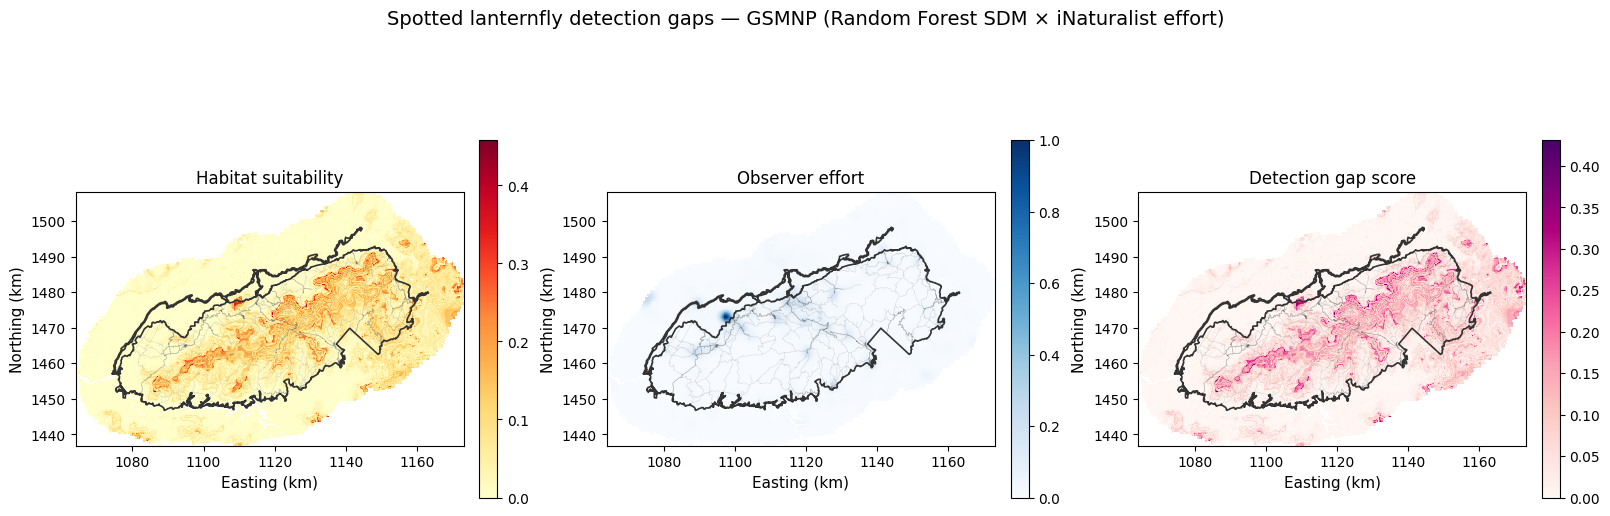

Saved: ./data/figures/detection_gap_map.png


In [20]:
Path('./data/figures').mkdir(exist_ok=True)

extent_m = [grid_bounds.left, grid_bounds.right, grid_bounds.bottom, grid_bounds.top]
km_fmt   = FuncFormatter(lambda x, _: f'{x/1000:.0f}')

panels = [
    (suit_display,   'YlOrRd', 'Habitat suitability'),
    (effort_display, 'Blues',  'Observer effort'),
    (gap,            'RdPu',   'Detection gap score'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)
fig.suptitle(
    'Spotted lanternfly detection gaps — GSMNP (Random Forest SDM × iNaturalist effort)',
    fontsize=14
)

for ax, (data, cmap, title) in zip(axes, panels):
    im = ax.imshow(
        data, cmap=cmap, origin='upper', extent=extent_m,
        interpolation='nearest', vmin=0
    )
    boundary.boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=3)
    roads.plot(ax=ax,  color='#666666', linewidth=0.4, alpha=0.6, zorder=2)
    trails.plot(ax=ax, color='#999999', linewidth=0.3, alpha=0.4, zorder=2)

    ax.xaxis.set_major_formatter(km_fmt)
    ax.yaxis.set_major_formatter(km_fmt)
    ax.set_xlabel('Easting (km)', fontsize=11)
    ax.set_ylabel('Northing (km)', fontsize=11)
    ax.set_title(title, fontsize=12)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.savefig('./data/figures/detection_gap_map.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ./data/figures/detection_gap_map.png")

## Output Summary

Three files produced, all in EPSG:5070, 250 m, 437 cols × 286 rows:

| File | Contents |
|------|----------|
| `./data/effort.tif` | Observer effort proxy, float32, [0, 1] over valid pixels |
| `./data/gap_score.tif` | Detection gap score, float32, NLCD 11/31/95 masked to NaN |
| `./data/figures/detection_gap_map.png` | Three-panel figure at 300 DPI |

**Interpreting the gap score:** The suitability values are presence-background RF outputs (relative, not calibrated probabilities), so the gap score's absolute scale is not meaningful — what matters is the spatial ranking. Cells near the top of the gap distribution are where the combination of modeled environmental suitability and low observer coverage is greatest. For field follow-up, these cells should be cross-referenced with the roads and trails overlay: high-gap cells adjacent to accessible trails are actionable; cells in remote old-growth wilderness require dedicated backcountry effort.